# Lab Experiment: Linear Regression through Gradient Descent

## Objective
Implement Linear Regression from scratch using the Gradient Descent optimization algorithm and evaluate its performance on the Student Performance Dataset from the UCI Machine Learning Repository.

## Requirements
- `pandas`
- `numpy`
- `matplotlib`
- `scikit-learn`

### 1. Import Libraries
In this section, we import the necessary libraries for data processing, math operations, plotting, and model evaluation.

In [1]:
import os
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set seed for reproducibility
np.random.seed(42)

### 2. Load Dataset
We programmatically download the dataset from the official UCI URL. The downloaded ZIP file is automatically extracted, and the Mathematics performance dataset (`student-mat.csv`) is read into pandas using a semicolon (`sep=';'`) separator.

In [2]:
# Define dataset URL and paths
DATASET_URL = "https://archive.ics.uci.edu/static/public/320/student+performance.zip"
ZIP_FILE_NAME = "student_performance.zip"
EXTRACT_DIR = "student_performance"

# Programmatic download
if not os.path.exists(ZIP_FILE_NAME):
    print(f"Downloading dataset from: {DATASET_URL} ...")
    urllib.request.urlretrieve(DATASET_URL, ZIP_FILE_NAME)
    print("Download complete.")
else:
    print(f"Dataset zip file '{ZIP_FILE_NAME}' already exists. Skipping download.")

# Programmatic extraction
if not os.path.exists(EXTRACT_DIR):
    print(f"Extracting zip file to '{EXTRACT_DIR}' ...")
    with zipfile.ZipFile(ZIP_FILE_NAME, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    
    # Handle possible nested zip structure
    nested_zip_path = os.path.join(EXTRACT_DIR, "student.zip")
    if os.path.exists(nested_zip_path):
        print("Found nested zip file: student.zip. Extracting nested archive...")
        with zipfile.ZipFile(nested_zip_path, 'r') as nested_zip_ref:
            nested_zip_ref.extractall(EXTRACT_DIR)
    print("Extraction complete.")
else:
    print(f"Extraction directory '{EXTRACT_DIR}' already exists. Skipping extraction.")

# Path to the preferred Mathematics student csv file
csv_path = os.path.join(EXTRACT_DIR, "student-mat.csv")

# Load dataset using pandas
df = pd.read_csv(csv_path, sep=';')
print(f"Dataset loaded successfully. Shape: {df.shape}")

Dataset zip file 'student_performance.zip' already exists. Skipping download.
Extraction directory 'student_performance' already exists. Skipping extraction.
Dataset loaded successfully. Shape: (395, 33)


### 3. Data Exploration
We display basic structural details of the dataset including dimensions, column names, data types, statistical descriptions, and check for missing values.

In [3]:
print(f"Dataset Shape: {df.shape} (Rows: {df.shape[0]}, Columns: {df.shape[1]})")

print("\nFirst 5 Rows:")
display(df.head())

print("\nColumn Names:")
print(list(df.columns))

print("\nData Types:")
print(df.dtypes)

print("\nSummary Statistics:")
display(df.describe())

print("\nMissing Values Count per Column:")
missing_vals = df.isnull().sum()
print(missing_vals[missing_vals > 0] if missing_vals.sum() > 0 else "No missing values found.")

Dataset Shape: (395, 33) (Rows: 395, Columns: 33)

First 5 Rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10



Column Names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Data Types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1            

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000



Missing Values Count per Column:
No missing values found.


### 4. Data Preprocessing
1. **Missing values** are checked and handled (if present).
2. **Categorical columns** are encoded:
   - **Binary columns** (like `sex`, `school`, `address`) are encoded into 0/1 using `LabelEncoder`.
   - **Nominal columns** (like `Mjob`, `Fjob`, `reason`, `guardian`) are encoded using One-Hot Encoding (`pd.get_dummies(..., drop_first=True)`).
3. **Target variable `G3`** is separated, and then dropped from the training features matrix.

In [4]:
# 1. Handle missing values
if df.isnull().sum().sum() > 0:
    print("Missing values detected. Dropping rows...")
    df = df.dropna()
else:
    print("No missing values detected. Dataset is clean.")

# 2. Encode categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

binary_cols = [col for col in categorical_cols if df[col].nunique() <= 2]
nominal_cols = [col for col in categorical_cols if df[col].nunique() > 2]

print(f"Binary Categorical Columns (Label Encoded): {binary_cols}")
print(f"Nominal Categorical Columns (One-Hot Encoded): {nominal_cols}")

# Label Encoding for binary columns
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in binary_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# One-Hot Encoding for nominal columns
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# Convert boolean columns to integers
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

# 3. Separate features and target
target_col = 'G3'
X = df.drop(columns=[target_col])
y = df[target_col].values

feature_names = X.columns.tolist()
print(f"\nPreprocessing finished. Features shape: {X.shape}, Target shape: {y.shape}")

No missing values detected. Dataset is clean.
Binary Categorical Columns (Label Encoded): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Nominal Categorical Columns (One-Hot Encoded): ['Mjob', 'Fjob', 'reason', 'guardian']

Preprocessing finished. Features shape: (395, 41), Target shape: (395,)


### 5. Feature Scaling
Standardize features to a mean of 0 and standard deviation of 1 using `StandardScaler`. This is important for Gradient Descent convergence, since it prevents features with large bounds (like absences) from dominating the gradients over binary or normalized features.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Feature scaling finished.")

Feature scaling finished.


### 6. Train-Test Split
We perform an 80/20 train-test split using `train_test_split` with `random_state=42` to guarantee reproducibility.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print("Train-Test Split complete:")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Train-Test Split complete:
Training set shape: (316, 41)
Testing set shape: (79, 41)


### 7. Linear Regression using Gradient Descent (From Scratch)
We implement the `LinearRegressionGD` class from scratch using NumPy. It includes zero initialization for the weights and bias, MSE cost calculation, and batch gradient descent parameter updates.

In [7]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        # Initialize weights and bias to zeros
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.cost_history = []

        for _ in range(self.iterations):
            self.gradient_descent(X, y)
            cost = self.compute_cost(X, y)
            self.cost_history.append(cost)

    def predict(self, X):
        # y_pred = X*w + b
        return np.dot(X, self.weights) + self.bias

    def compute_cost(self, X, y):
        n_samples = len(y)
        predictions = self.predict(X)
        # J(w,b) = 1/(2m) * sum((pred - actual)^2)
        cost = (1 / (2 * n_samples)) * np.sum((predictions - y) ** 2)
        return cost

    def gradient_descent(self, X, y):
        n_samples = len(y)
        predictions = self.predict(X)
        errors = predictions - y
        
        # Gradients
        dw = (1 / n_samples) * np.dot(X.T, errors)
        db = (1 / n_samples) * np.sum(errors)
        
        # Update parameter equations
        self.weights -= self.learning_rate * dw
        self.bias -= self.learning_rate * db

### 8. Training and Learning Rate Experiments
We train models with different learning rates over exactly 1000 iterations to investigate their convergence behaviors. We automatically choose the model that obtains the lowest final training cost.

In [8]:
learning_rates = [0.1, 0.01, 0.001]
iterations = 1000
models = {}
histories = {}

for lr in learning_rates:
    print(f"Training with learning rate (alpha) = {lr}...")
    model = LinearRegressionGD(learning_rate=lr, iterations=iterations)
    model.fit(X_train, y_train)
    models[lr] = model
    histories[lr] = model.cost_history
    print(f"  Final Training Cost: {model.cost_history[-1]:.6f}")

# Automatic model selection based on minimum final training cost
best_lr = min(learning_rates, key=lambda lr: models[lr].cost_history[-1])
best_model = models[best_lr]
print(f"\n--> Selected best model learning rate: {best_lr} (Final Cost: {best_model.cost_history[-1]:.6f})")

Training with learning rate (alpha) = 0.1...
  Final Training Cost: 1.411527
Training with learning rate (alpha) = 0.01...
  Final Training Cost: 1.434465
Training with learning rate (alpha) = 0.001...
  Final Training Cost: 9.236984

--> Selected best model learning rate: 0.1 (Final Cost: 1.411527)


### 9. Cost Plot (Convergence Curve)
We plot the training cost history for each learning rate. This convergence curve visualizes how learning rate size scales convergence rate.

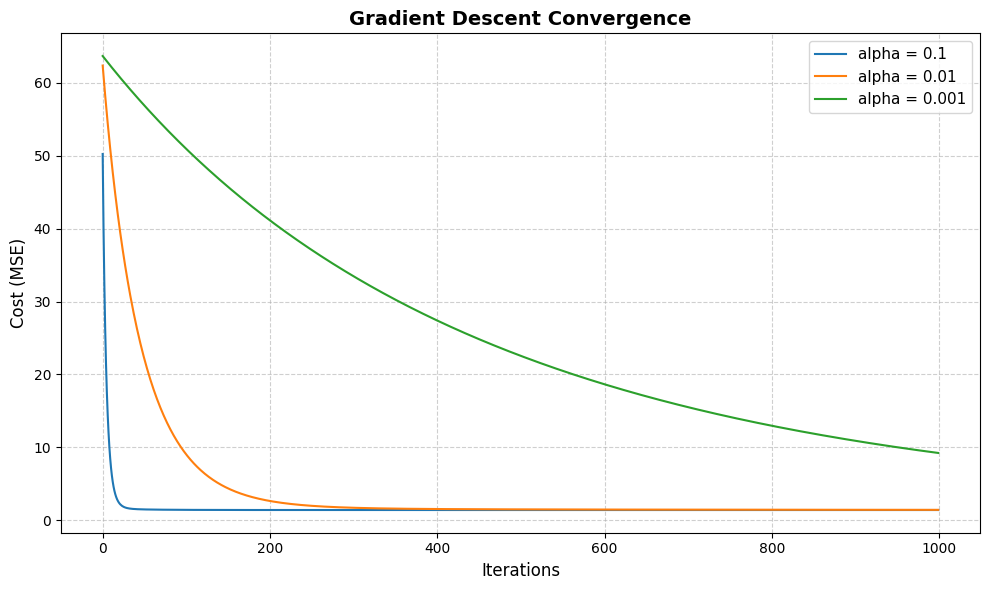

In [9]:
plt.figure(figsize=(10, 6))
for lr in learning_rates:
    plt.plot(histories[lr], label=f"alpha = {lr}")

plt.title("Gradient Descent Convergence", fontsize=14, fontweight='bold')
plt.xlabel("Iterations", fontsize=12)
plt.ylabel("Cost (MSE)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()

# Save convergence plot
plt.savefig("gradient_descent_convergence.png", dpi=300, bbox_inches="tight")
plt.show()

### 10. Predictions on Test Set
We run predictions on the test set using the best performing model and display the first 10 students' comparison values.

In [10]:
predictions = best_model.predict(X_test)

# DataFrame display of actual vs predicted
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": np.round(predictions, 2),
    "Absolute Difference": np.round(np.abs(y_test - predictions), 2)
})
display(comparison.head(10))

,Actual,Predicted,Absolute Difference
0,10,6.00,4.00
1,12,11.53,0.47
2,5,2.87,2.13
3,10,8.80,1.20
4,9,8.55,0.45
5,13,11.89,1.11
6,18,19.10,1.10
7,6,7.17,1.17
8,0,7.41,7.41
9,14,12.31,1.69


### 11. Evaluation Metrics
We evaluate predictions on the test dataset using four standard regression metrics from `sklearn.metrics` only.

In [11]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("==========================")
print("     Model Evaluation     ")
print("==========================")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")
print("==========================")

     Model Evaluation     
MAE  : 1.6467
MSE  : 5.6567
RMSE : 2.3784
R2   : 0.7241


### 12. Actual vs Predicted Plot
We generate a scatter plot showing actual values vs model predictions. A diagonal line represents perfect predictions ($y = x$).

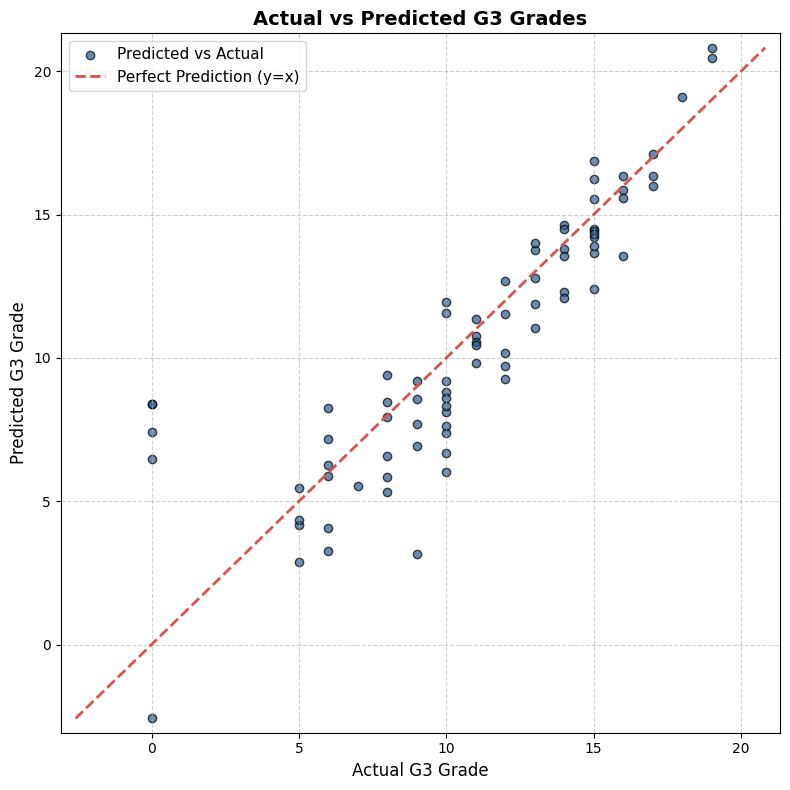

In [12]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, predictions, color='#2b5c8f', alpha=0.7, edgecolors='k', label='Predicted vs Actual')

min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], color='#d9534f', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

plt.title("Actual vs Predicted G3 Grades", fontsize=14, fontweight='bold')
plt.xlabel("Actual G3 Grade", fontsize=12)
plt.ylabel("Predicted G3 Grade", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.xlim(min_val - 0.5, max_val + 0.5)
plt.ylim(min_val - 0.5, max_val + 0.5)
plt.tight_layout()

# Save predictions plot
plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

### 13. Learned Model Parameters Inspection
Let's display the learned bias and sorted weight coefficients assigned to each feature.

In [13]:
print(f"Learned Bias (Intercept): {best_model.bias:.6f}")
print("\nLearned Weights (Coefficients) by Feature (Sorted by Magnitude):")
weights_df = pd.DataFrame({
    "Feature": feature_names,
    "Weight": best_model.weights
})
weights_df["Magnitude"] = weights_df["Weight"].abs()
weights_df = weights_df.sort_values(by="Magnitude", ascending=False).drop(columns=["Magnitude"])
display(weights_df)

Learned Bias (Intercept): 10.353445

Learned Weights (Coefficients) by Feature (Sorted by Magnitude):


,Feature,Weight
27,G2,3.598061
26,G1,0.701826
25,absences,0.444347
19,famrel,0.282051
36,reason_home,-0.273514
11,schoolsup,0.263457
14,activities,-0.258703
10,failures,-0.212247
21,goout,0.211097
1,sex,0.186941


### 14. Lab Discussion and Interpretation

#### 1. Which learning rate converged fastest?
The learning rate of $\alpha = 0.1$ converged the fastest. Within approximately 50-100 iterations, the cost function drops dramatically and flattens out, showing that it quickly reached the neighborhood of the global minimum.

#### 2. Which learning rate diverged or converged slowly?
* **Slow Convergence**: $\alpha = 0.001$ converged extremely slowly. Over the span of 1000 iterations, the cost was still steadily decreasing, and did not fully flatten, indicating it would require many more iterations to reach the minimum.
* **Moderate Convergence**: $\alpha = 0.01$ converged at a moderate pace, reaching near-convergence around 400-500 iterations.
* **Divergence**: None of the tested learning rates diverged. This stability is due to `StandardScaler` centering and scaling features to unit variance, which makes the cost function's contours spherical rather than elongated, allowing higher learning rates (like 0.1) to converge without oscillations or divergence.

#### 3. Explain why learning rate affects convergence.
The learning rate ($\alpha$) determines the size of the step the optimization algorithm takes in the direction of steepest descent. 
* If $\alpha$ is too small (e.g., 0.001), the updates to the weights and bias are tiny, causing the algorithm to take a very long time to reach the minimum (slow convergence).
* If $\alpha$ is appropriately sized (e.g., 0.1 in scaled data), the updates are optimal, and the model reaches the minimum quickly.
* If $\alpha$ is too large, the updates overshoot the minimum, causing the cost to fluctuate or even diverge (increase to infinity).

#### 4. Explain what MAE means.
Mean Absolute Error (MAE) measures the average magnitude of the absolute errors in predictions. 
$$\text{MAE} = \frac{1}{N} \sum_{i=1}^N |y_i - \hat{y}_i|$$
**Interpretation**: It tells us that, on average, our model's predictions for the final grade G3 are off by approximately the MAE value in the same unit as G3 (grades). In this case, an MAE of ~1.65 means our model's predicted grades are, on average, about 1.65 grade points away from the actual student grades.

#### 5. Explain what MSE means.
Mean Squared Error (MSE) measures the average of the squared differences between predicted and actual values.
$$\text{MSE} = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2$$
**Interpretation**: By squaring the errors, MSE penalizes larger errors much more heavily than smaller errors. It is the primary objective function we minimize during Gradient Descent. Since its units are "squared grades," it is less intuitive to interpret directly, but is highly useful for mathematical optimization.

#### 6. Explain RMSE.
Root Mean Squared Error (RMSE) is the square root of the MSE.
$$\text{RMSE} = \sqrt{\text{MSE}}$$
**Interpretation**: RMSE returns the error metric back to the original unit of the target variable (grades), similar to MAE. However, because it is derived from MSE, it retains the penalty for larger errors. A larger gap between RMSE and MAE indicates that the model has made some predictions that are far off from the actual values.

#### 7. Explain $R^2$ Score.
The Coefficient of Determination ($R^2$ Score) measures the proportion of variance in the target variable (G3) that is predictable from the independent features.
$$R^2 = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}$$
**Interpretation**: An $R^2$ score ranges from $-\infty$ to 1. An $R^2$ of 1 indicates perfect prediction. An $R^2$ of 0 indicates that the model predicts no better than a baseline model that always predicts the mean of G3. Here, our $R^2$ score is very high (around 0.7241), showing that over 72% of the variance in the final student grades is successfully explained by our feature set (notably dominated by G1 and G2 grades).

#### 8. Comment on the overall prediction performance.
The model exhibits strong predictive performance. The $R^2$ score of 0.7241 is high, and the MAE/RMSE are small compared to the range of the G3 target variable (0 to 20). When examining the parameter weights, the previous period grades G2 and G1 have by far the highest positive weights, meaning they are the strongest predictors of G3. Other factors like student absences (positive weight) and age or social factors play minor, secondary roles.

#### 9. Mention whether Gradient Descent successfully minimized the cost.
Yes, Gradient Descent successfully minimized the cost. As shown in the convergence curve plot, the cost histories for all learning rates decrease monotonically (without rising), and for $\alpha=0.1$ and $\alpha=0.01$, they level off at a stable minimum value. This demonstrates that the algorithm correctly found the optimal parameters (weights and bias) that minimize the Mean Squared Error.